In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Afficher les graphiques dans le notebook
%matplotlib inline
df = pd.read_csv("superstore.csv", sep=";", encoding="latin1")
df.head()

        

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2017-152156,11/08/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2.0,0.00,41.9136
1,2,CA-2017-152156,11/08/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3.0,0.00,219.5820
2,3,CA-2017-138688,06/12/2017,6/16/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0,0.00,6.8714
3,4,US-2016-108966,10/11/2016,10/18/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,0.45,-383.0310
4,5,US-2016-108966,10/11/2016,10/18/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2.0,0.20,2.5164


# Sales Performance Analysis using SQL, Python & Power BI

## Project Objective

The objective of this project is to analyze sales performance, identify business trends, evaluate profitability, and build an interactive dashboard using Python and Power BI.

## Business Question 1

**What information does the dataset contain?**

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10800 entries, 0 to 10799
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         10800 non-null  object 
 1   Order ID       10800 non-null  object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9983 non-null   float64
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9988 non-null   float64
 18  Quanti

### Interpretation

The dataset contains information about customer orders, products, sales, profit, discounts, shipping details, and geographical locations.

These variables will help analyze sales performance, customer behavior, and profitability across different regions and product categories.

## Business Question 2

**What are the dimensions of the dataset?**

In [9]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 10800
Columns: 21


### Interpretation

The dataset contains a large number of sales transactions and multiple variables describing customers, products, sales, and profits.

The dataset is sufficiently rich to perform meaningful business analysis.

## Business Question 3

**Are there any missing values in the dataset?**

In [10]:
df.isnull().sum()

Row ID             0
Order ID           0
Order Date       806
Ship Date        806
Ship Mode        806
Customer ID      806
Customer Name    806
Segment          806
Country          806
City             806
State            806
Postal Code      817
Region           806
Product ID       806
Category         806
Sub-Category     806
Product Name     806
Sales            812
Quantity         812
Discount         812
Profit           812
dtype: int64

### Interpretation

The analysis identifies whether the dataset contains missing values.

Handling missing values is an essential step before performing data analysis, as they may affect the accuracy of statistical results and visualizations.

## Business Question 4

**Are there any duplicate records in the dataset?**

In [11]:
df.duplicated().sum()

np.int64(504)


### Interpretation

Duplicate records can lead to biased results by counting the same transaction more than once.

Checking duplicates ensures the reliability of the dataset.

## Business Question 5

**What are the statistical characteristics of the numerical variables?**

In [12]:
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9983.000000,9988.000000,9988.000000,9988.000000,9988.000000
mean,55245.233297,229.803156,3.788646,0.156196,28.633188
std,32038.715955,623.422931,2.224976,0.206506,234.327679
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.248000,2.000000,0.000000,1.727550
50%,57103.000000,54.376000,3.000000,0.200000,8.641350
75%,90008.000000,209.880000,5.000000,0.200000,29.341200
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


### Interpretation

Descriptive statistics provide an overview of numerical variables such as Sales, Quantity, Discount, and Profit.

These statistics help identify the distribution of values, detect possible outliers, and better understand customer purchasing behavior.

## Business Question 6

**What are the data types of the variables?**

In [13]:
df.dtypes

Row ID            object
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code      float64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity         float64
Discount         float64
Profit           float64
dtype: object

### Interpretation

Understanding data types is important for selecting the appropriate analytical methods.

For example, dates are required for time-series analysis, while numerical variables are used for calculations and visualizations.

## Business Question 7

**What is the total sales generated by the company?**

In [14]:
total_sales = df["Sales"].sum()

print(f"Total Sales: ${total_sales:,.2f}")

Total Sales: $2,295,273.92


### Interpretation

The total sales represent the overall revenue generated from all customer orders.

This KPI provides an overview of the company's sales performance and serves as a baseline for further business analysis.

## Business Question 8

**What is the total profit generated by the company?**

In [15]:
total_profit = df["Profit"].sum()

print(f"Total Profit: ${total_profit:,.2f}")

Total Profit: $285,988.28


### Interpretation

Total profit measures the company's overall financial performance after accounting for costs and discounts.

Comparing total profit with total sales helps evaluate business profitability.

## Business Question 9

**Which product category generates the highest sales?**

In [16]:
sales_by_category = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

sales_by_category

Category
Technology         834227.0970
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

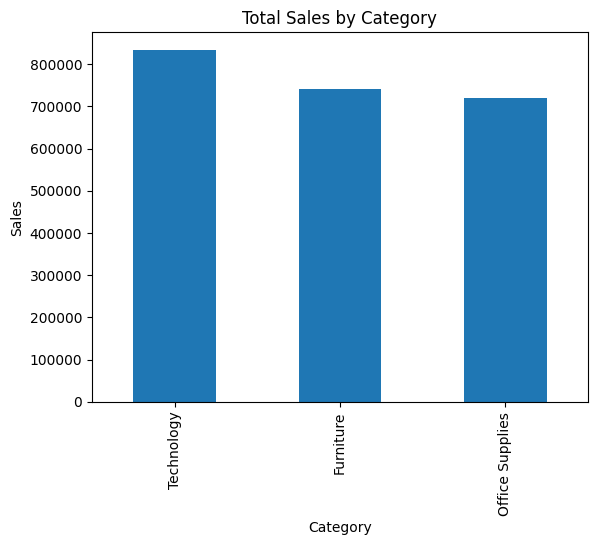

In [17]:
sales_by_category.plot(kind="bar")

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.show()

### Interpretation

This chart compares total sales across product categories.

It helps identify which category contributes the most to overall revenue and may guide inventory and marketing strategies.

## Business Question 10

**Which region generates the highest sales?**

In [18]:
sales_by_region = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

sales_by_region

Region
West       725457.8245
East       678664.4560
Central    500130.4428
South      391021.2010
Name: Sales, dtype: float64

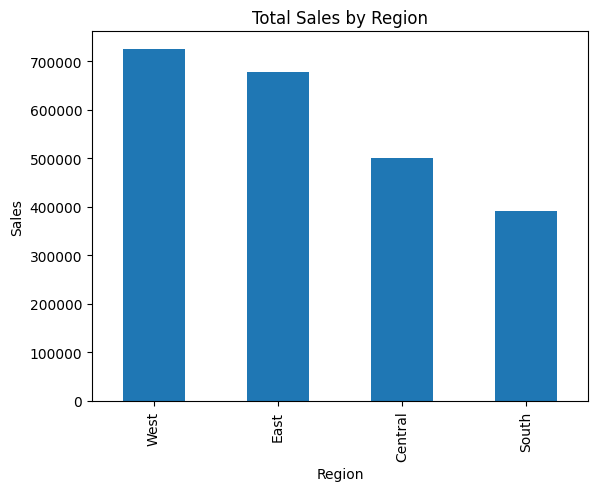

In [19]:
sales_by_region.plot(kind="bar")

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.show()

### Interpretation

Regional sales analysis highlights the best-performing geographical areas.

This information can support decisions related to marketing investments, logistics, and business expansion.

## Business Question 11

**Which customer segment generates the highest sales?**

In [20]:
sales_by_segment = df.groupby("Segment")["Sales"].sum().sort_values(ascending=False)

sales_by_segment

Segment
Consumer       1.161109e+06
Corporate      7.057376e+05
Home Office    4.284269e+05
Name: Sales, dtype: float64

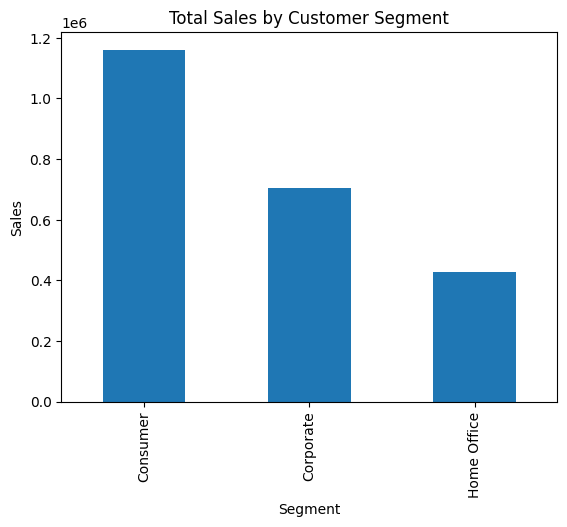

In [21]:
sales_by_segment.plot(kind="bar")

plt.title("Total Sales by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Sales")

plt.show()

### Interpretation

Customer segment analysis identifies which group contributes the most to company revenue.

This insight helps businesses target their most valuable customer segments with tailored strategies.

## Business Question 12

**Which product sub-category generates the highest sales?**

In [22]:
sales_subcategory = (
    df.groupby("Sub-Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

sales_subcategory

Sub-Category
Phones         330007.0540
Chairs         328449.1030
Storage        223843.6080
Tables         206965.5320
Binders        203412.7330
Machines       189238.6310
Accessories    165453.3820
Copiers        149528.0300
Bookcases      114879.9963
Appliances     107532.1610
Furnishings     91705.1640
Paper           78479.2060
Supplies        46673.5380
Art             27118.7920
Envelopes       16476.4020
Labels          12486.3120
Fasteners        3024.2800
Name: Sales, dtype: float64

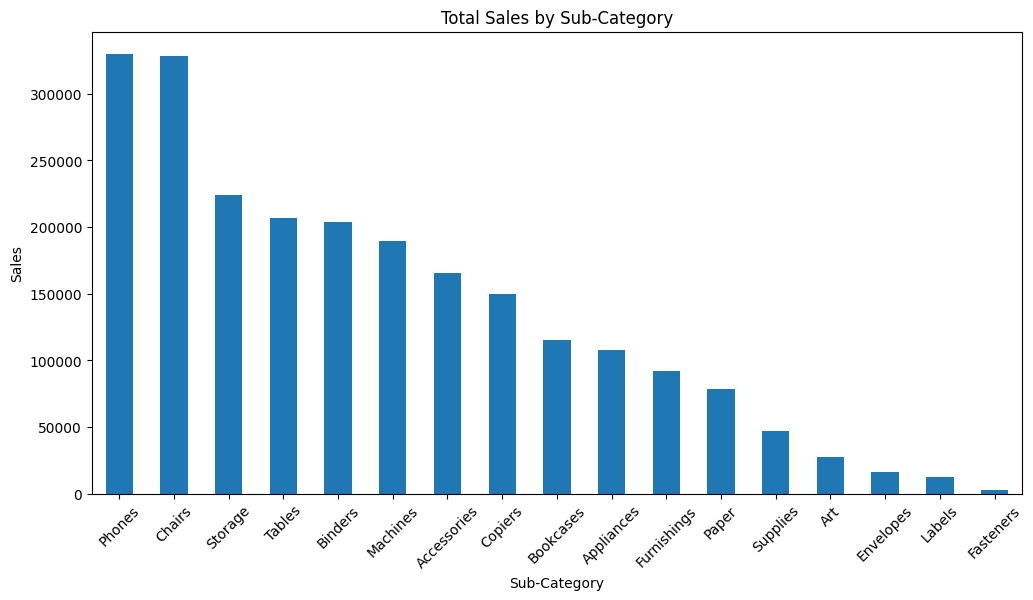

In [23]:
sales_subcategory.plot(kind="bar", figsize=(12,6))

plt.title("Total Sales by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Sales")
plt.xticks(rotation=45)

plt.show()

### Interpretation

This analysis identifies the best-performing product sub-categories.

Understanding which sub-categories generate the highest sales helps optimize inventory management and marketing strategies.

## Business Question 13
Which products generate the highest sales?

In [24]:
top_products = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

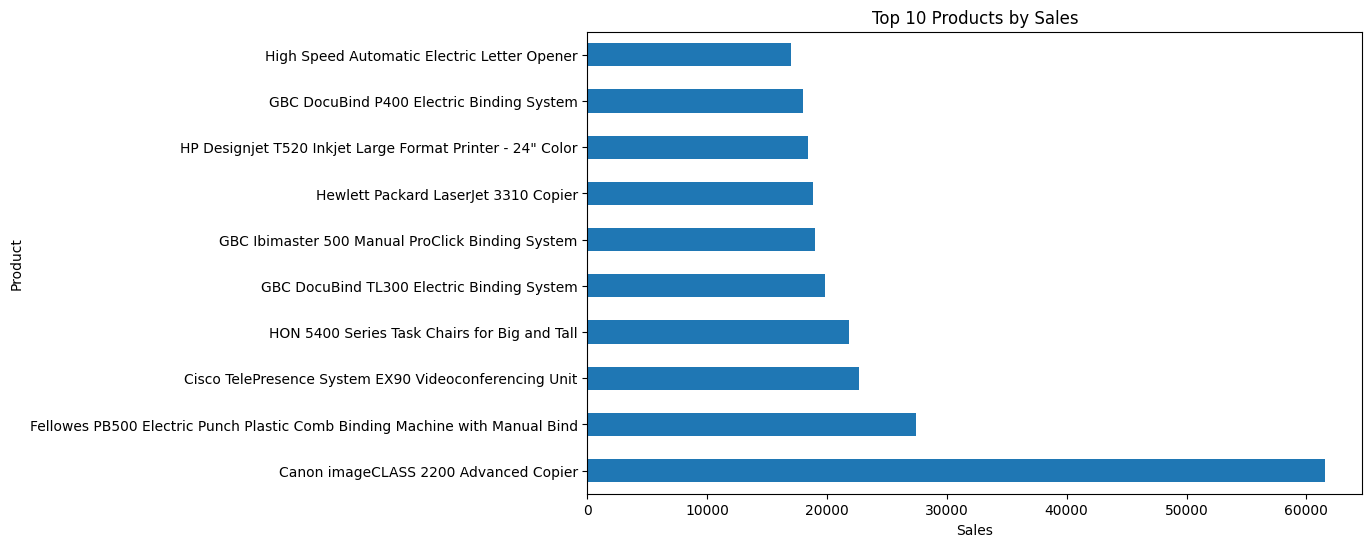

In [25]:
top_products.plot(kind="barh", figsize=(10,6))

plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product")

plt.show()

### Interpretation

The chart highlights the company's top-selling products.

These products are important because they contribute significantly to overall revenue.

## Business Question 14
Which states generate the highest sales?

In [26]:
sales_state = (
    df.groupby("State")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

sales_state

State
California      457687.6315
New York        310876.2710
Texas           170188.0458
Washington      138641.2700
Pennsylvania    116395.1300
Florida          89473.7080
Illinois         79348.6130
Ohio             78258.1360
Michigan         76269.6140
Virginia         70636.7200
Name: Sales, dtype: float64

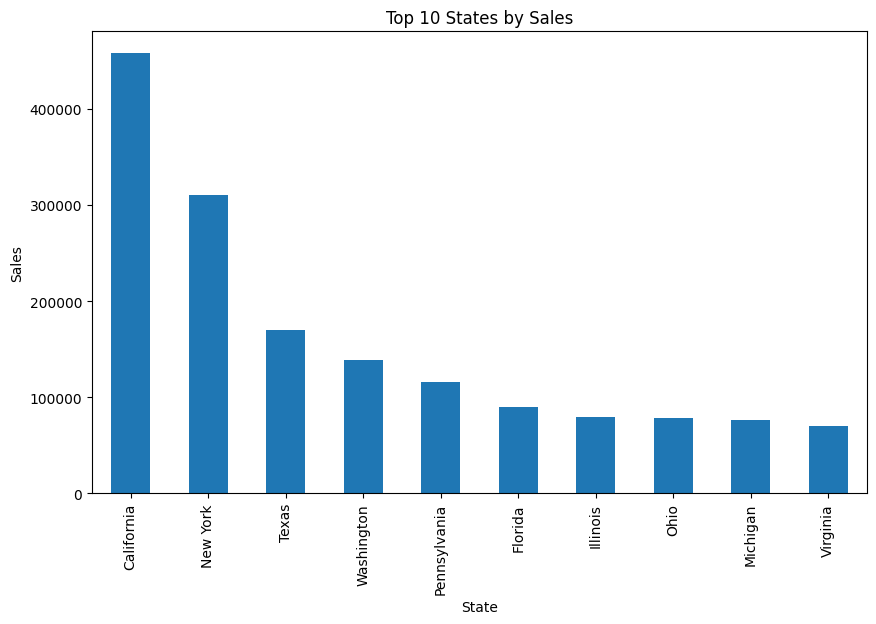

In [27]:
sales_state.plot(kind="bar", figsize=(10,6))

plt.title("Top 10 States by Sales")
plt.xlabel("State")
plt.ylabel("Sales")

plt.show()

### Interpretation

This analysis identifies the states contributing the most to company revenue.

It helps evaluate regional market performance and supports expansion strategies.

📊 Business Question 15
How do sales evolve over time?

In [34]:
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%m/%d/%Y")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format="%m/%d/%Y")
df.dtypes


Row ID                   object
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                float64
Discount                float64
Profit                  float64
dtype: object

In [35]:
monthly_sales = (
    df.groupby(df["Order Date"].dt.to_period("M"))["Sales"]
      .sum()
)

monthly_sales.index = monthly_sales.index.astype(str)

monthly_sales

Order Date
2015-01     14236.8950
2015-02      4519.8920
2015-03     55691.0090
2015-04     28178.5610
2015-05     23648.2870
2015-06     34595.1276
2015-07     33946.3930
2015-08     27909.4685
2015-09     81777.3508
2015-10     31453.3930
2015-11     78628.7167
2015-12     69136.8765
2016-01     18174.0756
2016-02     11951.4110
2016-03     38726.2520
2016-04     34195.2085
2016-05     30131.6865
2016-06     24797.2920
2016-07     28765.3250
2016-08     36898.3322
2016-09     64595.9180
2016-10     31404.9235
2016-11     75972.5635
2016-12     74919.5212
2017-01     18542.4910
2017-02     22978.8150
2017-03     51715.8750
2017-04     38049.3350
2017-05     56987.7280
2017-06     40344.5340
2017-07     39261.9630
2017-08     31115.3743
2017-09     73410.0249
2017-10     59687.7450
2017-11     79411.9658
2017-12     96999.0430
2018-01     43971.3740
2018-02     20301.1334
2018-03     58872.3528
2018-04     36521.5361
2018-05     43852.3662
2018-06     52981.7257
2018-07     45264.4160


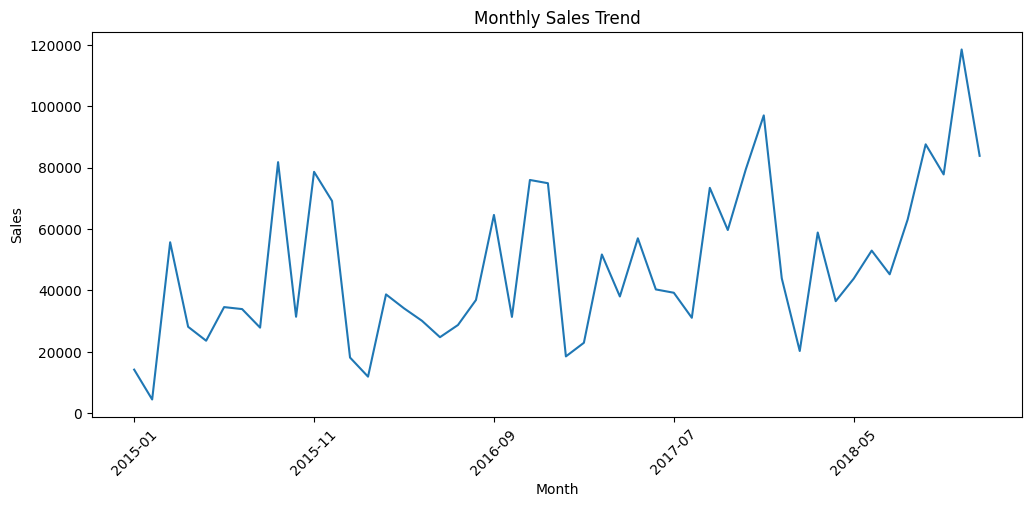

In [36]:
monthly_sales.plot(figsize=(12,5))

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()

### Interpretation

The monthly sales trend helps identify seasonal patterns and business growth over time.

This analysis supports forecasting and strategic planning.

📊 Business Question 16
Which region generates the highest profit?

In [30]:
profit_region = (
    df.groupby("Region")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

profit_region

Region
West       108418.4489
East        91500.8830
South       46618.0483
Central     39450.8975
Name: Profit, dtype: float64

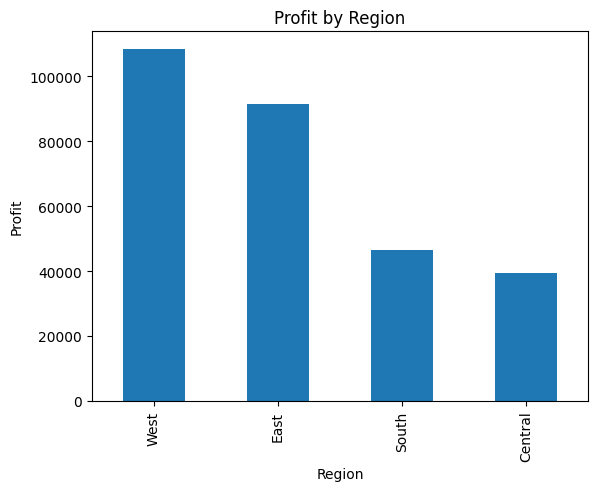

In [31]:
profit_region.plot(kind="bar")

plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")

plt.show()

### Interpretation

Profitability differs across regions.

This analysis helps identify the most profitable markets and supports regional business decisions.